# Amazon Digital Music - Recommender System

**Dataset**: [Digital_Music_5 (5-core subset)](https://cseweb.ucsd.edu/~jmcauley/datasets/amazon_v2/)  

In [ ]:
import os, gzip, json, math, time, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.notebook import tqdm

sns.set_theme(style='whitegrid', palette='muted')
os.makedirs('output', exist_ok=True)

## 1. Download & Load Dataset

In [4]:
DATASET_URL  = 'https://jmcauley.ucsd.edu/data/amazon_v2/categoryFilesSmall/Digital_Music_5.json.gz'
DATASET_FILE = 'Digital_Music_5.json.gz'
TOP_K = 10

if not os.path.exists(DATASET_FILE):
    print('Downloading ...')
    with requests.get(DATASET_URL, stream=True, timeout=120) as r:
        r.raise_for_status()
        with open(DATASET_FILE, 'wb') as f:
            for chunk in r.iter_content(1<<16):
                f.write(chunk)
    print('Done.')
else:
    print(f'File exists: {DATASET_FILE}')

records = []
with gzip.open(DATASET_FILE, 'rt', encoding='utf-8') as f:
    for line in f:
        d = json.loads(line)
        records.append({
            'user_id':   d.get('reviewerID'),
            'item_id':   d.get('asin'),
            'rating':    float(d.get('overall', 0)),
            'timestamp': int(d.get('unixReviewTime', 0)),
        })

df = pd.DataFrame(records).dropna(subset=['user_id','item_id','rating'])
df = df.sort_values(['user_id','timestamp']).reset_index(drop=True)
print(f'Loaded {len(df):,} interactions')

File exists: Digital_Music_5.json.gz
Loaded 169,781 interactions


## 2. Exploratory Data Analysis

In [5]:
print('=== Dataset Summary ==='
)
print(f"Total interactions : {len(df):,}")
print(f"Unique users        : {df.user_id.nunique():,}")
print(f"Unique items        : {df.item_id.nunique():,}")
print(f"Rating range        : {df.rating.min()} – {df.rating.max()}")
print(f"Mean rating         : {df.rating.mean():.3f}")
density = len(df) / (df.user_id.nunique() * df.item_id.nunique()) * 100
print(f"Matrix density      : {density:.4f}%")

ints_per_user = df.groupby('user_id').size()
ints_per_item = df.groupby('item_id').size()
print(f"Avg interactions/user : {ints_per_user.mean():.2f}")
print(f"Avg interactions/item : {ints_per_item.mean():.2f}")

=== Dataset Summary ===
Total interactions : 169,781
Unique users        : 16,566
Unique items        : 11,797
Rating range        : 1.0 – 5.0
Mean rating         : 4.700
Matrix density      : 0.0869%
Avg interactions/user : 10.25
Avg interactions/item : 14.39


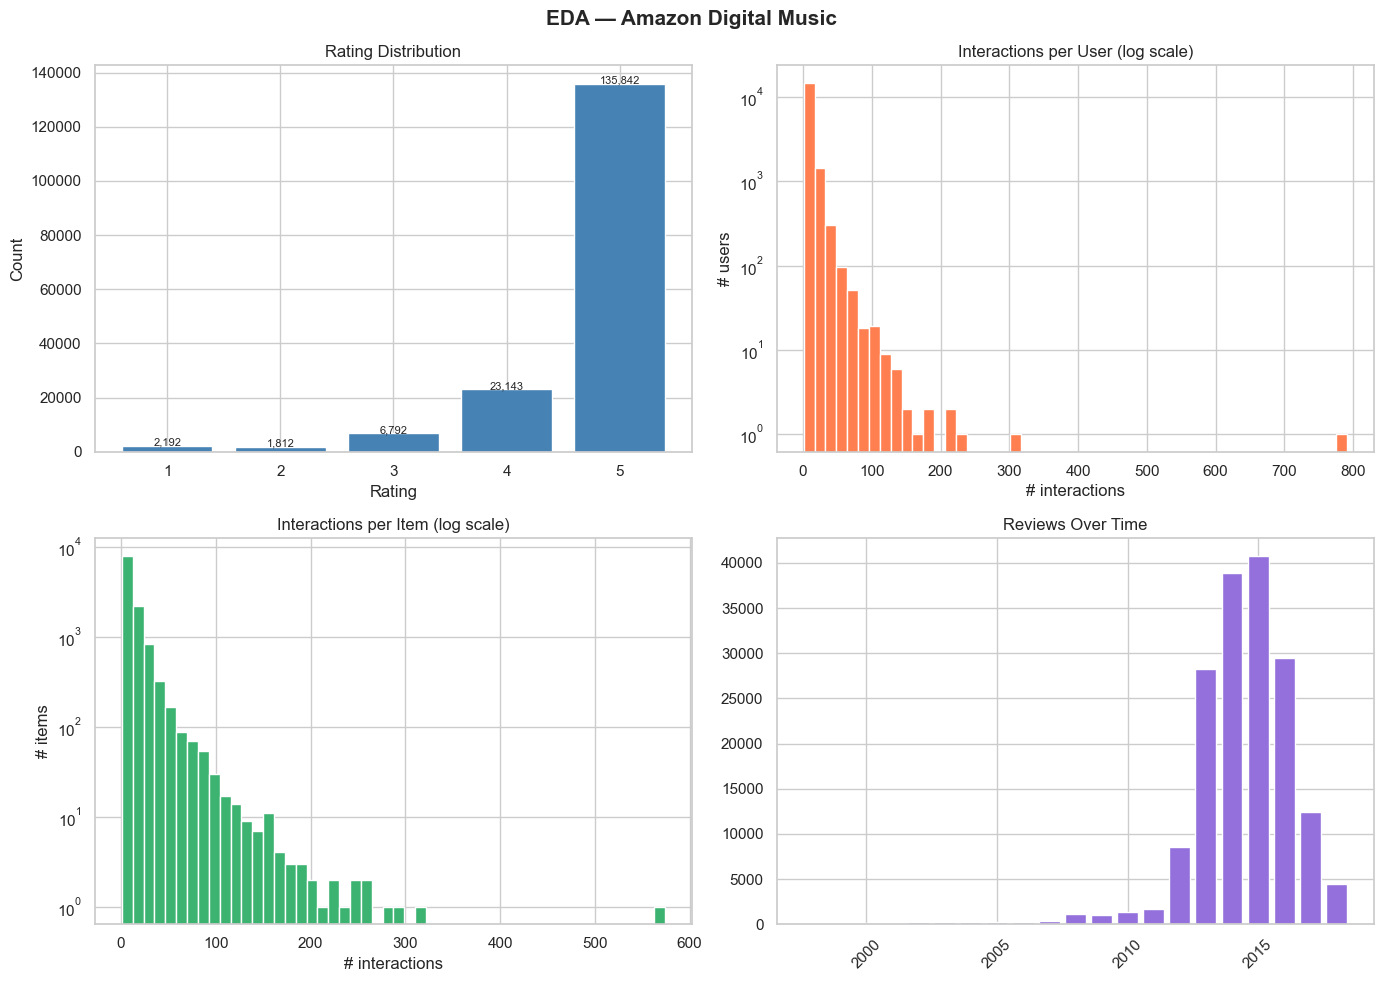

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA — Amazon Digital Music', fontsize=15, fontweight='bold')

# 1. Rating distribution
rating_counts = df['rating'].value_counts().sort_index()
axes[0,0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='white')
axes[0,0].set_title('Rating Distribution')
axes[0,0].set_xlabel('Rating'); axes[0,0].set_ylabel('Count')
for x, y in zip(rating_counts.index, rating_counts.values):
    axes[0,0].text(x, y+50, f'{y:,}', ha='center', fontsize=8)

# 2. Interactions per user
axes[0,1].hist(ints_per_user, bins=50, color='coral', edgecolor='white', log=True)
axes[0,1].set_title('Interactions per User (log scale)')
axes[0,1].set_xlabel('# interactions'); axes[0,1].set_ylabel('# users')

# 3. Interactions per item
axes[1,0].hist(ints_per_item, bins=50, color='mediumseagreen', edgecolor='white', log=True)
axes[1,0].set_title('Interactions per Item (log scale)')
axes[1,0].set_xlabel('# interactions'); axes[1,0].set_ylabel('# items')

# 4. Reviews over time
df['year'] = pd.to_datetime(df['timestamp'], unit='s', errors='coerce').dt.year
yearly = df['year'].value_counts().sort_index().dropna()
axes[1,1].bar(yearly.index.astype(int), yearly.values, color='mediumpurple', edgecolor='white')
axes[1,1].set_title('Reviews Over Time'); axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('output/eda_plots.png', dpi=150)
plt.show()

### Выводы
EDA: 80% оценок - пятёрки, матрица разреженная (0.087%), распределения пользователей и товаров по взаимодействиям следуют степенному закону, пик активности - 2015–2016 гг.

## 3. Leave-One-Out Split

Для каждого пользователя в качестве тестового элемента сохраняется **последнее взаимодействие** (по временной метке).  

Все предыдущие взаимодействия проходят обучение. 

Это стандартный протокол оценки для систем рекомендаций с последовательной/неявной обратной связью.

In [7]:
df_sorted = df.sort_values(['user_id','timestamp'])
last_idx  = df_sorted.groupby('user_id').tail(1).index
test_df   = df_sorted.loc[last_idx].copy()
train_df  = df_sorted.drop(index=last_idx).copy()

common_users = set(train_df.user_id) & set(test_df.user_id)
train_df = train_df[train_df.user_id.isin(common_users)].reset_index(drop=True)
test_df  = test_df[test_df.user_id.isin(common_users)].reset_index(drop=True)

print(f'Train: {len(train_df):,} rows, {train_df.user_id.nunique():,} users')
print(f'Test : {len(test_df):,}  rows, {test_df.user_id.nunique():,} users')

Train: 153,215 rows, 16,564 users
Test : 16,564  rows, 16,564 users


## 4. Evaluation Metrics

| Метрика | Формула | Значение |
|--------|---------|---------|
| **HR@K** | 1 if relevant ∈ top-K else 0 | Был ли настоящий товар в списке top-K? |
| **MRR@K** | 1/rank if found else 0 | Насколько высоким (ранним) был истинный показатель? |
| **NDCG@K** | 1/log₂(rank+1) if found else 0 | Значимость, взвешенная по рангу |
| **Coverage** | \|unique recommended items\| / \|all items\| | Разнообразие каталогов |


In [8]:
def hr_at_k(recs, relevant, k=TOP_K):
    return 1.0 if relevant in recs[:k] else 0.0

def mrr_at_k(recs, relevant, k=TOP_K):
    for i, item in enumerate(recs[:k]):
        if item == relevant: return 1.0 / (i+1)
    return 0.0

def ndcg_at_k(recs, relevant, k=TOP_K):
    for i, item in enumerate(recs[:k]):
        if item == relevant: return 1.0 / math.log2(i+2)
    return 0.0

def evaluate(model_name, recommendations, test_df, all_items, k=TOP_K):
    test_map = dict(zip(test_df.user_id, test_df.item_id))
    hr, mrr, ndcg = [], [], []
    for user, recs in recommendations.items():
        if user not in test_map: continue
        rel = test_map[user]
        hr.append(hr_at_k(recs, rel, k))
        mrr.append(mrr_at_k(recs, rel, k))
        ndcg.append(ndcg_at_k(recs, rel, k))
    rec_items = set(item for r in recommendations.values() for item in r)
    coverage  = len(rec_items) / len(all_items) * 100
    return {
        'Model': model_name, 'HR@10': np.mean(hr),
        'MRR@10': np.mean(mrr), 'NDCG@10': np.mean(ndcg),
        'Coverage': coverage, 'N_users': len(hr)
    }

## 5. Recommendation Models

### 5.1 Popularity Baseline

In [9]:
# Sort items by interaction count globally
popular_items = (
    train_df.groupby('item_id').size()
    .sort_values(ascending=False)
    .index.tolist()
)

seen_by_user = train_df.groupby('user_id')['item_id'].apply(set).to_dict()
all_items    = set(train_df.item_id)

pop_recs = {
    u: [i for i in popular_items if i not in seen_by_user.get(u, set())][:TOP_K]
    for u in test_df.user_id
}
print('Popularity recs ready.')

Popularity recs ready.


### 5.2 User-Based Collaborative Filtering

In [10]:
users = train_df.user_id.unique().tolist()
items = train_df.item_id.unique().tolist()
u2i = {u: i for i, u in enumerate(users)}
i2i = {it: i for i, it in enumerate(items)}

rows_idx = train_df.user_id.map(u2i)
cols_idx = train_df.item_id.map(i2i)
R = csr_matrix((train_df.rating.values.astype(np.float32),
               (rows_idx, cols_idx)),
               shape=(len(users), len(items)))

sim_matrix = cosine_similarity(R, dense_output=False)
print('Similarity matrix computed.')

N_NEIGHBORS = 50
def ucf_recommend(user_id, seen, k=TOP_K):
    if user_id not in u2i: return []
    uid = u2i[user_id]
    sim_row = np.array(sim_matrix[uid].todense()).flatten()
    sim_row[uid] = 0.0
    top_n = np.argsort(sim_row)[::-1][:N_NEIGHBORS]
    scores = np.zeros(len(items))
    for ni, w in zip(top_n, sim_row[top_n]):
        if w <= 0: break
        scores += w * np.array(R[ni].todense()).flatten()
    for item in seen:
        if item in i2i: scores[i2i[item]] = 0.0
    top_idx = np.argsort(scores)[::-1][:k]
    return [items[i] for i in top_idx if scores[i] > 0]

ucf_recs = {u: ucf_recommend(u, seen_by_user.get(u, set())) for u in tqdm(test_df.user_id)}
print('User-CF recs ready.')

Similarity matrix computed.


  0%|          | 0/16564 [00:00<?, ?it/s]

User-CF recs ready.


### 5.3 SVD Matrix Factorization

In [11]:
N_FACTORS = 50
k_svd = min(N_FACTORS, min(R.shape) - 1)
U, sigma, Vt = svds(R.astype(np.float64), k=k_svd)
scores_matrix = U @ np.diag(sigma) @ Vt   # shape: (users x items)
print(f'SVD done. Score matrix shape: {scores_matrix.shape}')

def svd_recommend(user_id, seen, k=TOP_K):
    if user_id not in u2i: return []
    uid = u2i[user_id]
    sc = scores_matrix[uid].copy()
    for item in seen:
        if item in i2i: sc[i2i[item]] = -np.inf
    top_idx = np.argsort(sc)[::-1][:k]
    return [items[i] for i in top_idx]

svd_recs = {u: svd_recommend(u, seen_by_user.get(u, set())) for u in tqdm(test_df.user_id)}
print('SVD-MF recs ready.')

SVD done. Score matrix shape: (16564, 11784)


  0%|          | 0/16564 [00:00<?, ?it/s]

SVD-MF recs ready.


## 6. Evaluation & Results

In [12]:
results = [
    evaluate('Popularity', pop_recs, test_df, all_items),
    evaluate('User-CF',    ucf_recs, test_df, all_items),
    evaluate('SVD-MF',     svd_recs, test_df, all_items),
]
results_df = pd.DataFrame(results)
results_df.to_csv('output/results.csv', index=False)
results_df.style.format({
    'HR@10': '{:.4f}', 'MRR@10': '{:.4f}',
    'NDCG@10': '{:.4f}', 'Coverage': '{:.2f}%'
})

,Model,HR@10,MRR@10,NDCG@10,Coverage,N_users
0,Popularity,0.0119,0.0055,0.0070,0.15%,16564
1,User-CF,0.0696,0.0362,0.0441,66.53%,16564
2,SVD-MF,0.0184,0.0074,0.0099,4.95%,16564


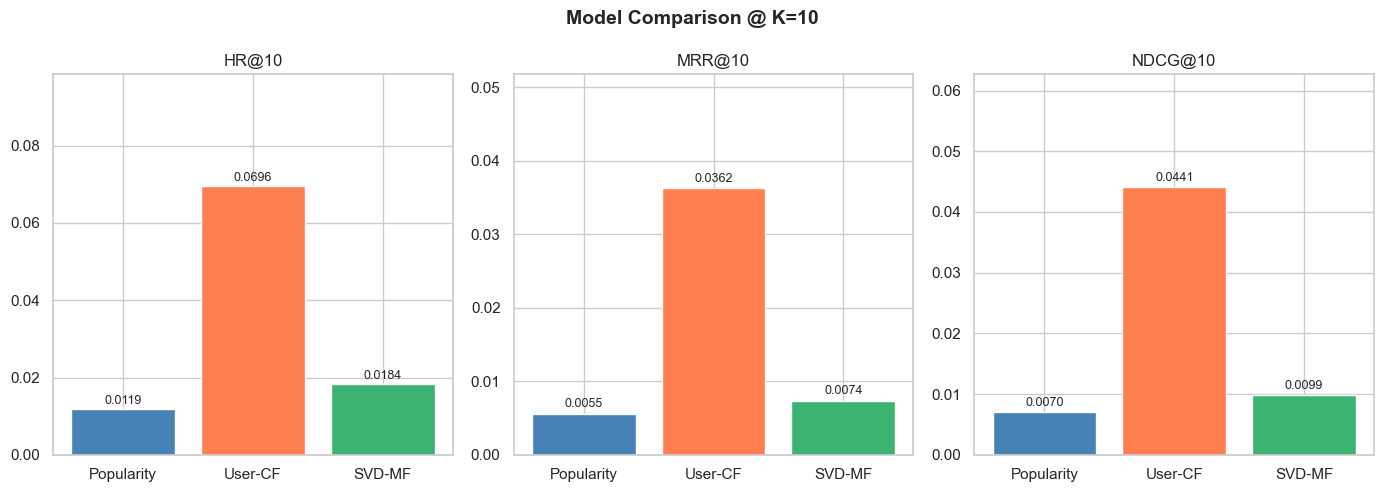

In [13]:
metrics = ['HR@10', 'MRR@10', 'NDCG@10']
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Model Comparison @ K=10', fontsize=14, fontweight='bold')
colors = ['steelblue', 'coral', 'mediumseagreen']

for ax, metric in zip(axes, metrics):
    vals = results_df.set_index('Model')[metric]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='white')
    ax.set_title(metric)
    ax.set_ylim(0, min(vals.max()*1.4+0.001, 1.0))
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('output/model_comparison.png', dpi=150)
plt.show()

## 7. Выводы

User-CF - лучший результат по всем метрикам (HR@10 = 0.070, NDCG@10 = 0.044, Coverage = 66.5%): нишевая структура музыкального каталога хорошо ловится косинусным сходством.

SVD-MF - слабее ожидаемого (HR@10 = 0.018): truncated SVD оптимизирует MSE, а не ранжирование; к тому же низкий coverage (5%) указывает на схлопывание рекомендаций в небольшой популярный сет.

Popularity - наихудшая точность (HR@10 = 0.012) и вырожденный coverage (0.15% ≈ 18 товаров из 11 797): полное отсутствие персонализации.